In [24]:
!pip install imblearn

Defaulting to user installation because normal site-packages is not writeable


In [62]:
import pandas as pd 
import os
import matplotlib.pyplot as plt
import numpy as np
import mne
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC 
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler

In [134]:
feature_df = pd.read_csv('../data/processed/feature_df.csv')

In [135]:
feature_df

,hjorth_activity_EEG.AF3,hjorth_activity_EEG.F7,hjorth_activity_EEG.F3,hjorth_activity_EEG.FC5,hjorth_activity_EEG.T7,hjorth_activity_EEG.P7,hjorth_activity_EEG.O1,hjorth_activity_EEG.O2,hjorth_activity_EEG.P8,hjorth_activity_EEG.T8,...,katz_FD_EEG.F4,katz_FD_EEG.F8,katz_FD_EEG.AF4,BMu Ratio,Delta,Theta,Alpha,Beta,Mu,Label
0,8835.169964,3284.168283,825.633937,508.573071,385.243031,2127.179811,424.999363,4069.315155,170602.133878,2164.720436,...,2.373949,1.774361,2.469726,0.154077,206.713435,5.083967,4.819005,0.882015,5.724520,1
1,3121.463877,10122.588973,897.237434,1285.113833,1193.675642,1441.639231,960.973453,46649.765055,35207.111161,1673.734739,...,1.967430,1.699146,1.877878,0.086824,344.087159,9.844358,5.966924,0.570836,6.574599,3
2,3548.548527,6361.893880,561.668005,1359.497231,347.418699,600.978508,106.071255,1897.535948,70975.602663,4462.007405,...,2.477925,1.889780,2.150383,0.104618,227.458633,6.424897,5.305853,0.598586,5.721643,4
3,4308.105945,8692.674785,2260.013153,1669.867390,743.467180,1446.750039,580.763366,20775.896232,74374.453068,43742.118796,...,1.989519,1.381289,1.910310,0.055527,507.928829,4.936909,7.238155,0.434128,7.818310,0
4,4866.063412,59668.314466,892.759103,939.587539,1652.086267,4643.623851,437.029243,7366.268641,52914.022718,13251.058986,...,2.135992,1.900289,2.143163,0.199239,611.181766,9.596300,3.639729,0.649666,3.260731,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,3360.579618,228.311899,77.543992,458.964991,693.975904,48107.961102,1816.307713,135.813444,85.443050,578.541331,...,1.984261,1.789928,1.844183,0.524192,197.779992,4.657350,0.736580,0.288429,0.550237,3
84,2550.045304,68.790172,64.573847,1461.559821,163.936854,277.628793,252.341378,74.691287,51.339438,114.441306,...,2.080070,2.004242,1.798263,0.080120,132.105626,11.470851,2.140260,0.330464,4.124604,4
85,2550.045304,68.790172,64.573847,1461.559821,163.936854,277.628793,252.341378,74.691287,51.339438,114.441306,...,2.080070,2.004242,1.798263,0.080120,132.105626,11.470851,2.140260,0.330464,4.124604,4
86,3519.972335,514.330172,109.559685,1041.985732,227.424180,885.180403,259.347690,83.544157,84.089270,478.325553,...,1.907183,1.803343,1.821610,0.909776,54.909941,3.716239,0.463259,0.238123,0.261738,2


In [ ]:
feature_df['Label'].value_counts()

Label
1    77
0    11
Name: count, dtype: int64

In [119]:
small_1 = feature_df[feature_df['Label'] == 1].sample(n=11)

In [123]:
feature_df = pd.concat([feature_df[feature_df['Label'] == 0], small_1])

In [149]:
y = feature_df['Label']
X = feature_df.drop(columns = 'Label')

clf = svm.SVC()  

In [150]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3333, random_state=17)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.666, random_state=17)


# binary classification

### OVERSAMPLING / SMOTE

In [148]:
feature_df.loc[feature_df['Label'] != 0, 'Label'] = 1
feature_df

,hjorth_activity_EEG.AF3,hjorth_activity_EEG.F7,hjorth_activity_EEG.F3,hjorth_activity_EEG.FC5,hjorth_activity_EEG.T7,hjorth_activity_EEG.P7,hjorth_activity_EEG.O1,hjorth_activity_EEG.O2,hjorth_activity_EEG.P8,hjorth_activity_EEG.T8,...,katz_FD_EEG.F4,katz_FD_EEG.F8,katz_FD_EEG.AF4,BMu Ratio,Delta,Theta,Alpha,Beta,Mu,Label
0,8835.169964,3284.168283,825.633937,508.573071,385.243031,2127.179811,424.999363,4069.315155,170602.133878,2164.720436,...,2.373949,1.774361,2.469726,0.154077,206.713435,5.083967,4.819005,0.882015,5.724520,1
1,3121.463877,10122.588973,897.237434,1285.113833,1193.675642,1441.639231,960.973453,46649.765055,35207.111161,1673.734739,...,1.967430,1.699146,1.877878,0.086824,344.087159,9.844358,5.966924,0.570836,6.574599,1
2,3548.548527,6361.893880,561.668005,1359.497231,347.418699,600.978508,106.071255,1897.535948,70975.602663,4462.007405,...,2.477925,1.889780,2.150383,0.104618,227.458633,6.424897,5.305853,0.598586,5.721643,1
3,4308.105945,8692.674785,2260.013153,1669.867390,743.467180,1446.750039,580.763366,20775.896232,74374.453068,43742.118796,...,1.989519,1.381289,1.910310,0.055527,507.928829,4.936909,7.238155,0.434128,7.818310,0
4,4866.063412,59668.314466,892.759103,939.587539,1652.086267,4643.623851,437.029243,7366.268641,52914.022718,13251.058986,...,2.135992,1.900289,2.143163,0.199239,611.181766,9.596300,3.639729,0.649666,3.260731,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,3360.579618,228.311899,77.543992,458.964991,693.975904,48107.961102,1816.307713,135.813444,85.443050,578.541331,...,1.984261,1.789928,1.844183,0.524192,197.779992,4.657350,0.736580,0.288429,0.550237,1
84,2550.045304,68.790172,64.573847,1461.559821,163.936854,277.628793,252.341378,74.691287,51.339438,114.441306,...,2.080070,2.004242,1.798263,0.080120,132.105626,11.470851,2.140260,0.330464,4.124604,1
85,2550.045304,68.790172,64.573847,1461.559821,163.936854,277.628793,252.341378,74.691287,51.339438,114.441306,...,2.080070,2.004242,1.798263,0.080120,132.105626,11.470851,2.140260,0.330464,4.124604,1
86,3519.972335,514.330172,109.559685,1041.985732,227.424180,885.180403,259.347690,83.544157,84.089270,478.325553,...,1.907183,1.803343,1.821610,0.909776,54.909941,3.716239,0.463259,0.238123,0.261738,1


In [43]:
def oversample(df):
    classes = df.label.value_counts().to_dict()
    most = max(classes.values())
    classes_list = []
    for key in classes:
        classes_list.append(df[df['Label'] == key]) 
    classes_sample = []
    for i in range(1,len(classes_list)):
        classes_sample.append(classes_list[i].sample(most, replace=True))
    df_maybe = pd.concat(classes_sample)
    final_df = pd.concat([df_maybe,classes_list[0]], axis=0)
    final_df = final_df.reset_index(drop=True)
    return final_df

In [26]:
def oversample_smote(df, target_column):
    smote = SMOTE()
    X = df.drop(target_column, axis=1)
    y = df[target_column]
    X_oversampled, y_oversampled = smote.fit_resample(X, y)
    df_oversampled = pd.concat([pd.DataFrame(X_oversampled, columns=X.columns), pd.Series(y_oversampled, name=target_column)], axis=1)
    return df_oversampled

In [44]:
oversampled_df = oversample_smote(feature_df, 'Label')

In [45]:
oversampled_df['Label'].value_counts()

Label
1    77
0    77
Name: count, dtype: int64

In [63]:
y = oversampled_df['Label']
X = oversampled_df.drop(columns = 'Label')

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3333, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.666, random_state=42)

In [151]:
ros = RandomOverSampler(random_state=0)
ros.fit(X, y)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

In [152]:
y_resampled.value_counts()

Label
1    50
0    50
Name: count, dtype: int64

### logistic regression

In [69]:
logreg = LogisticRegression(random_state=16)

# fit the model with data
logreg.fit(X_resampled, y_resampled)

y_pred = logreg.predict(X_val)

print('Model accuracy score with default hyperparameters: {0:0.4f}'. format(accuracy_score(y_val, y_pred)))

Model accuracy score with default hyperparameters: 0.7059


C:\Users\lizoc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


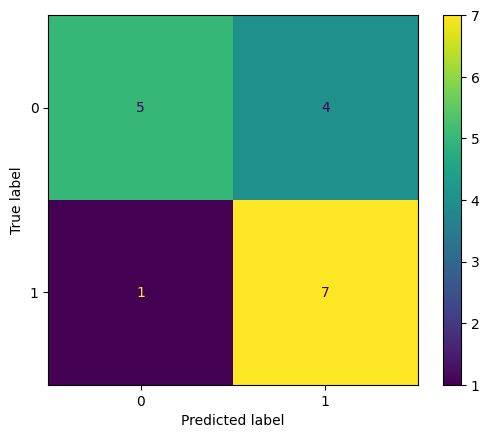

In [70]:
cm = confusion_matrix(y_val, y_pred, labels=logreg.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=logreg.classes_)
disp.plot()

# EDA

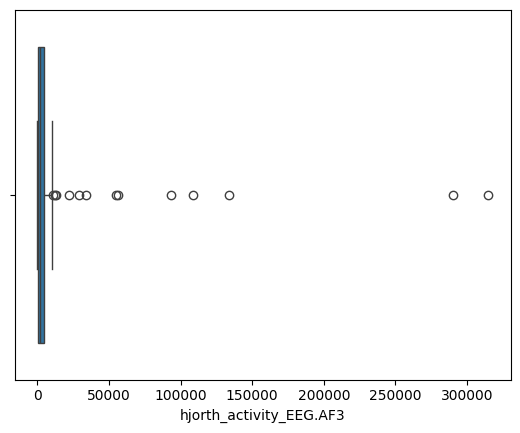

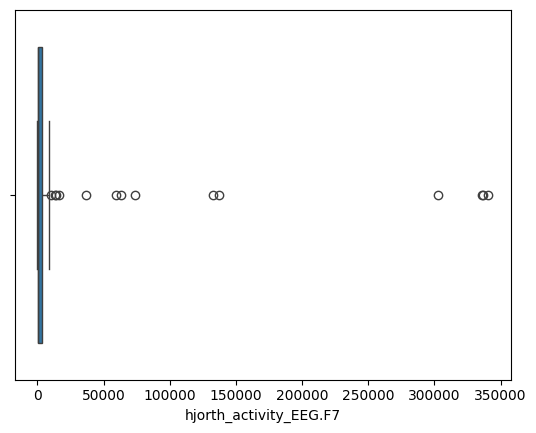

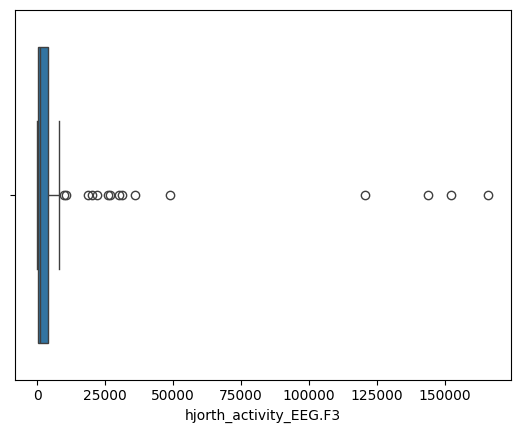

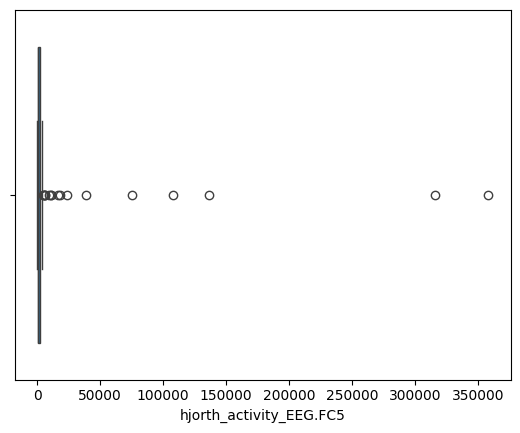

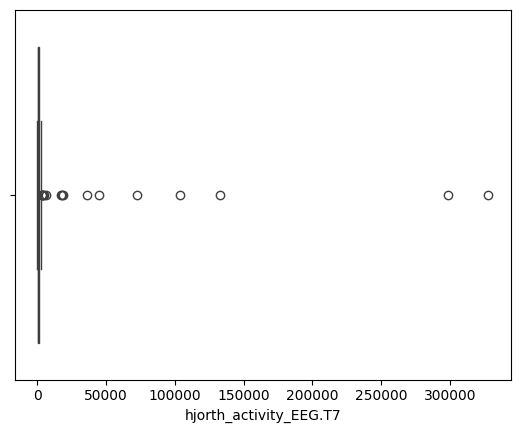

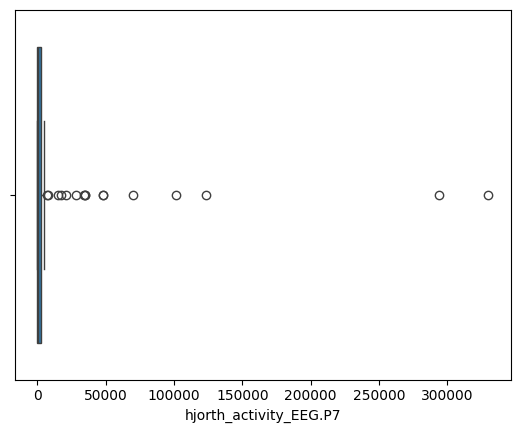

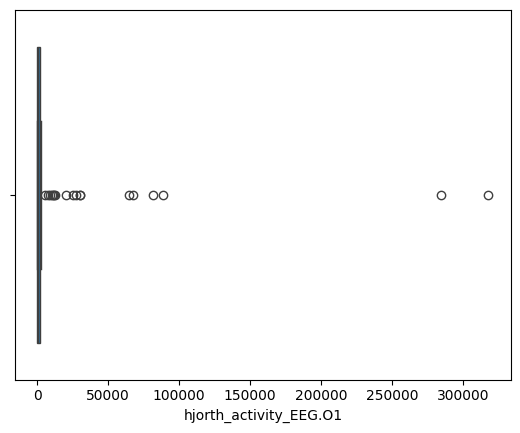

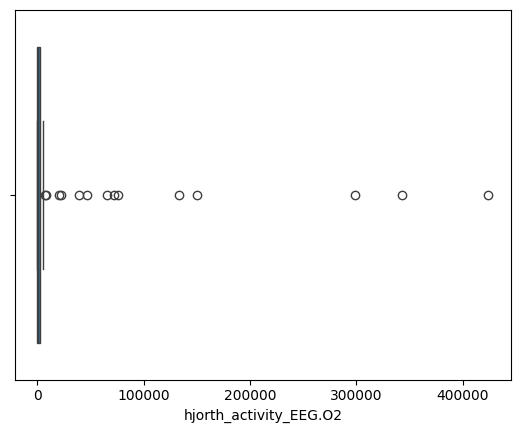

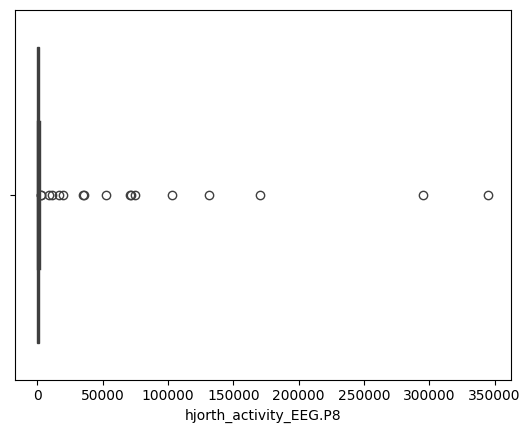

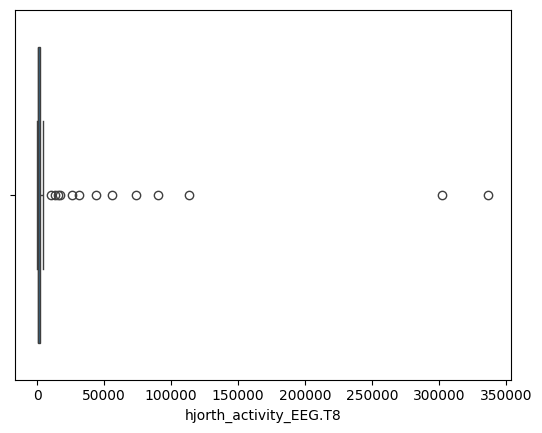

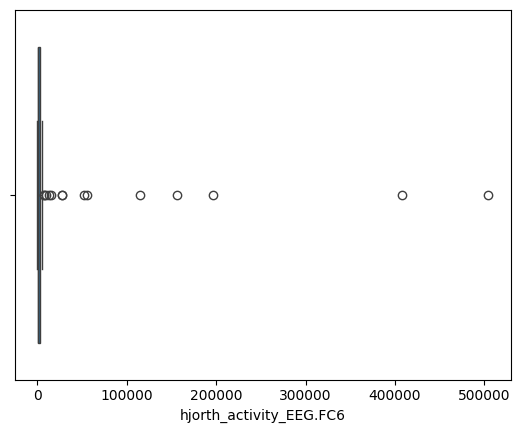

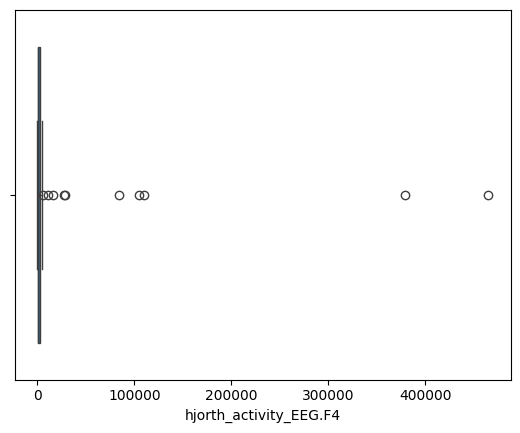

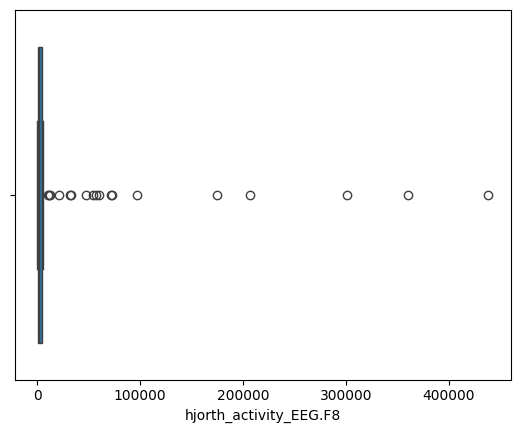

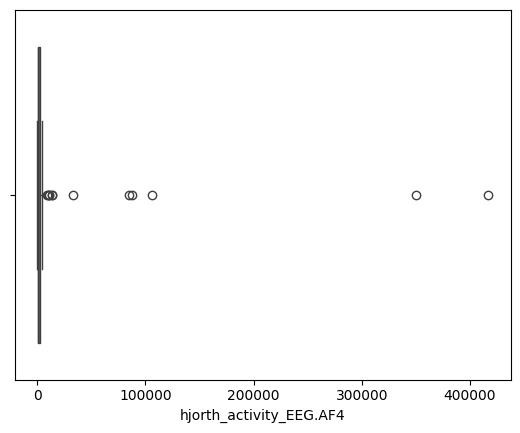

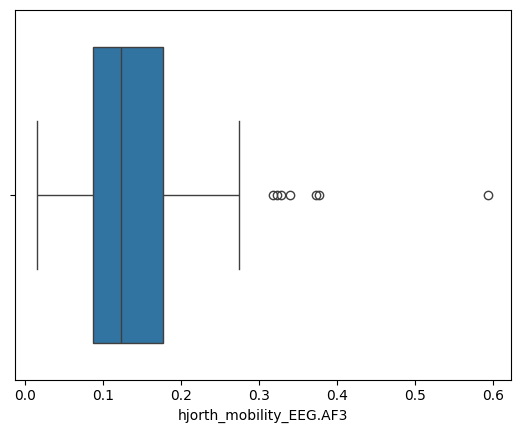

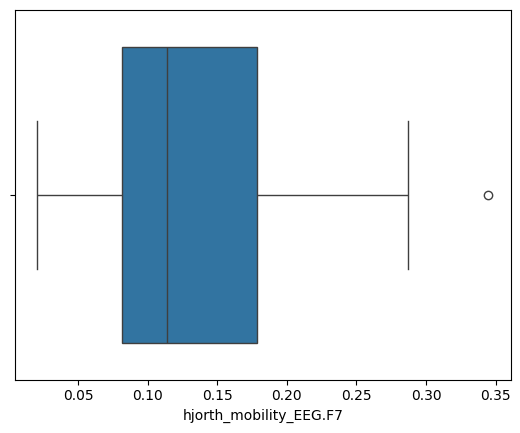

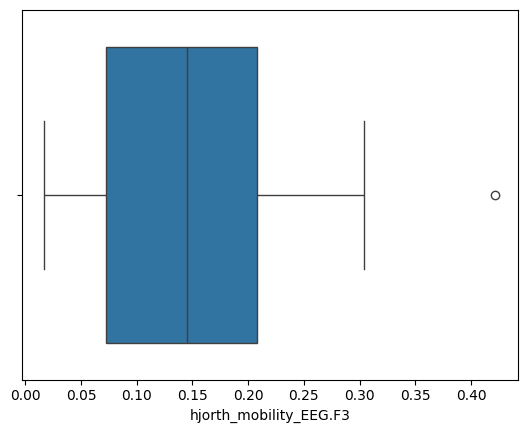

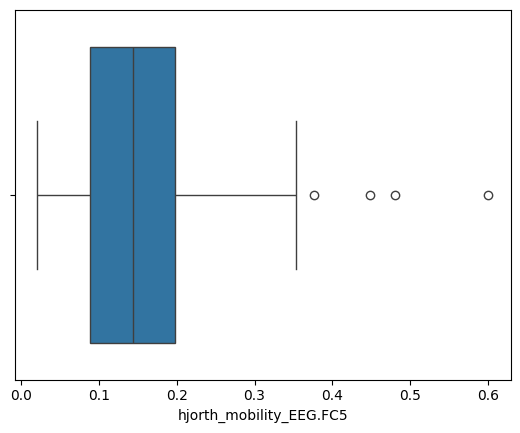

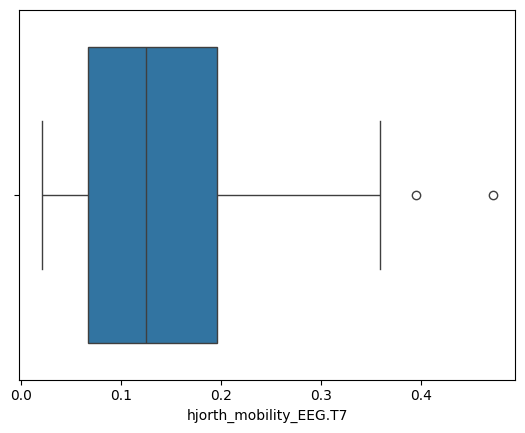

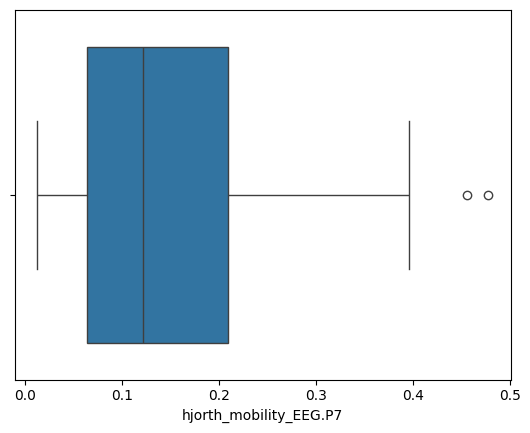

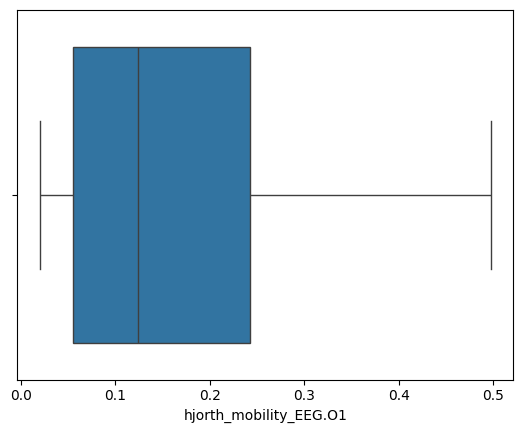

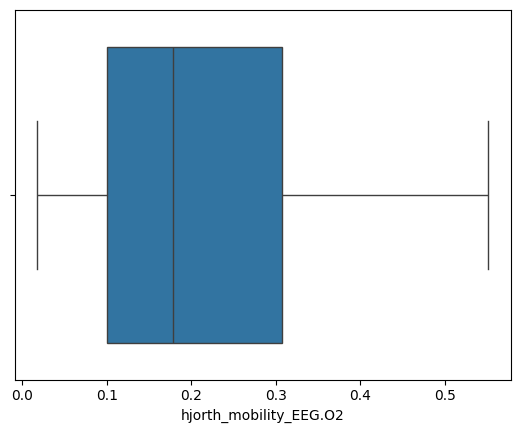

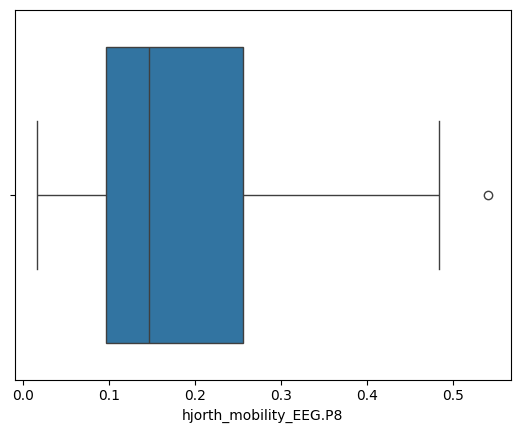

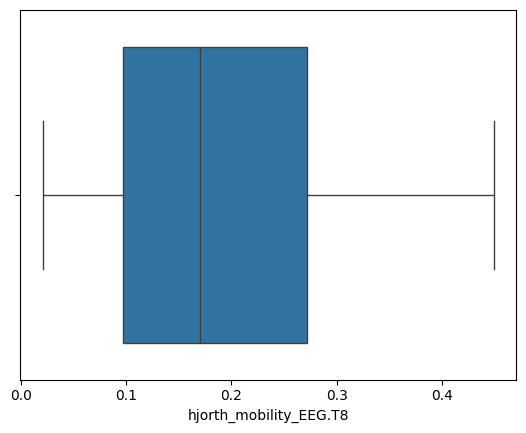

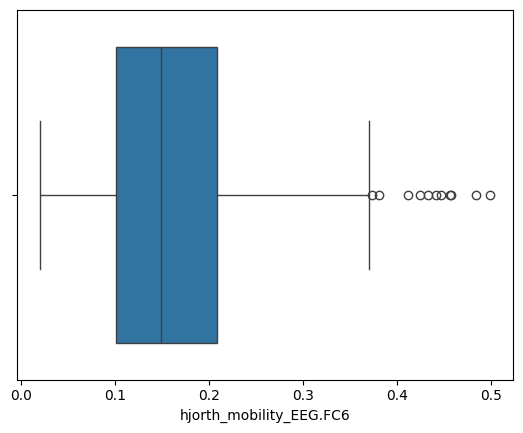

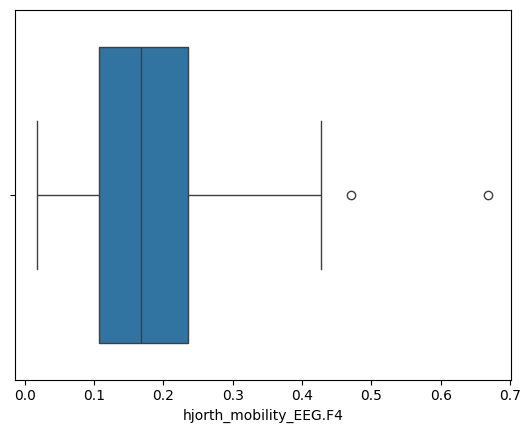

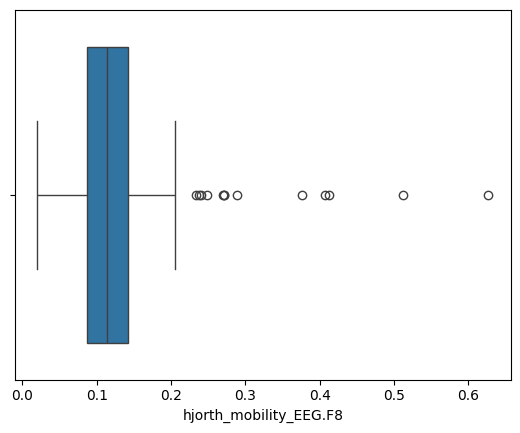

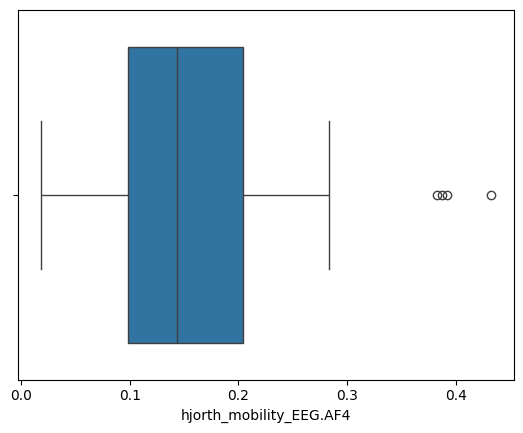

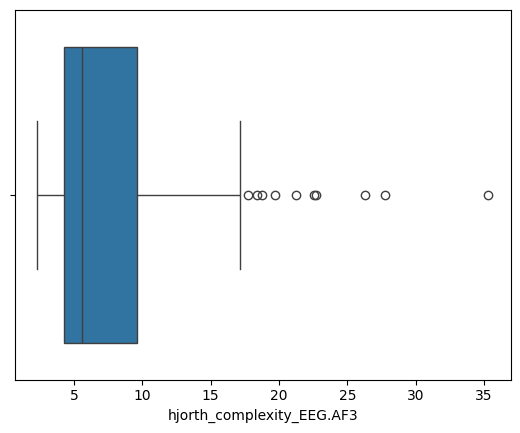

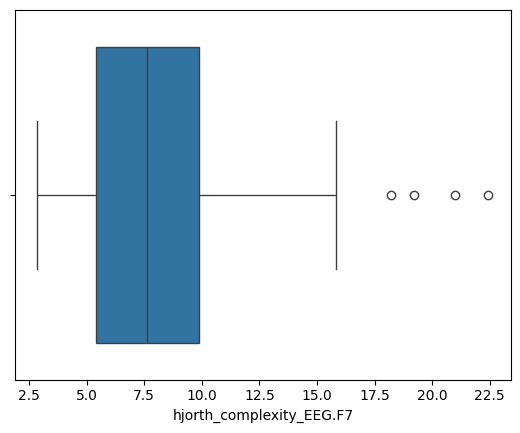

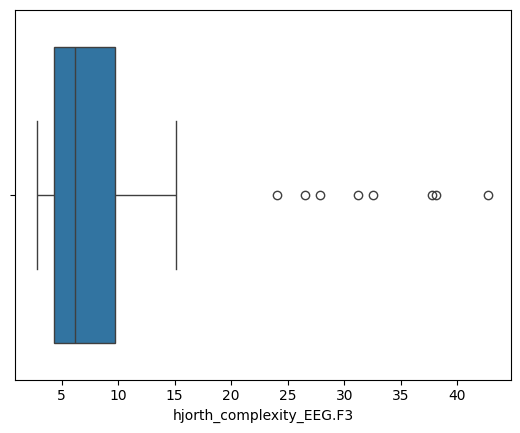

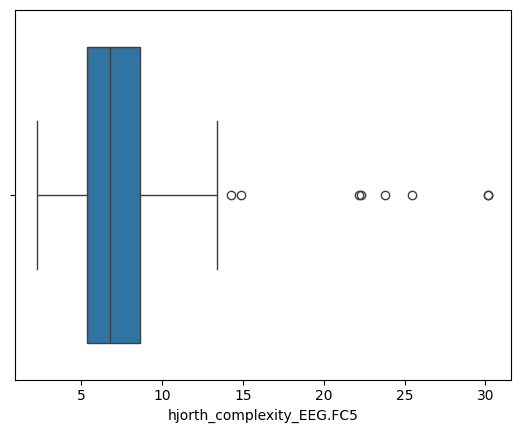

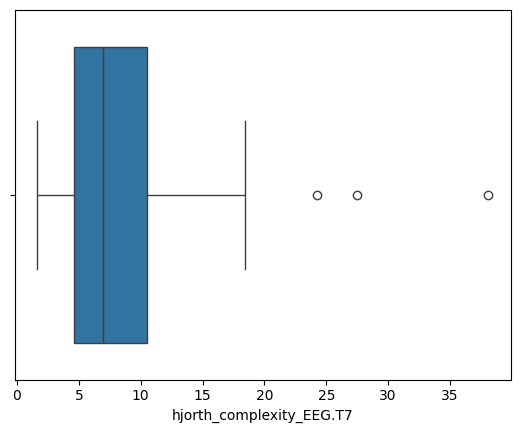

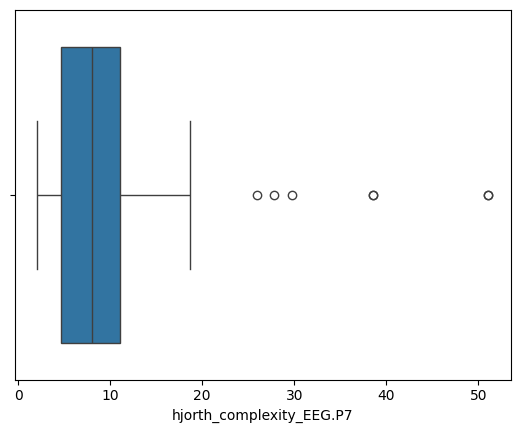

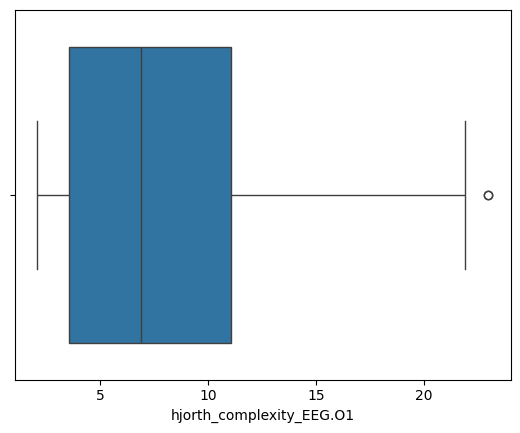

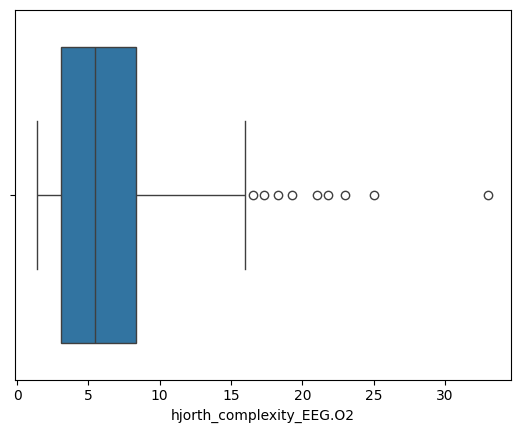

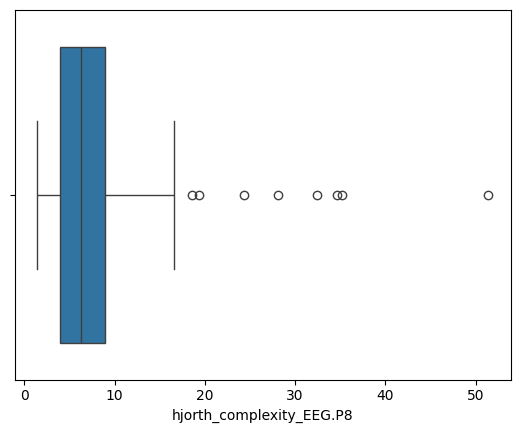

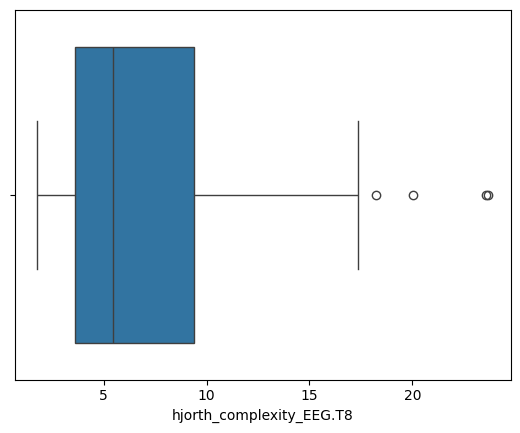

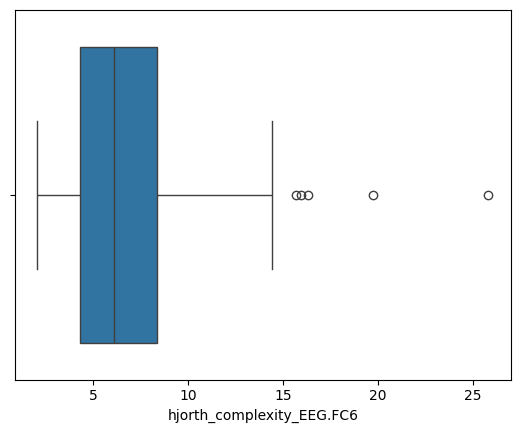

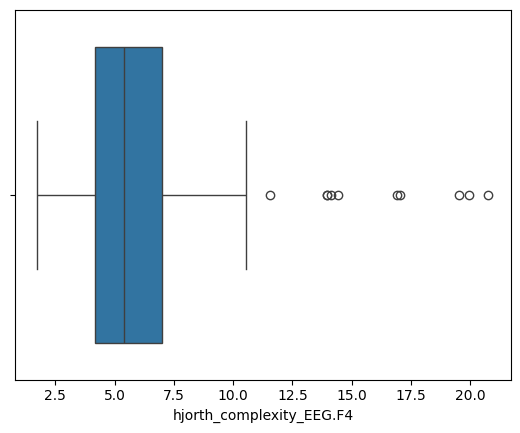

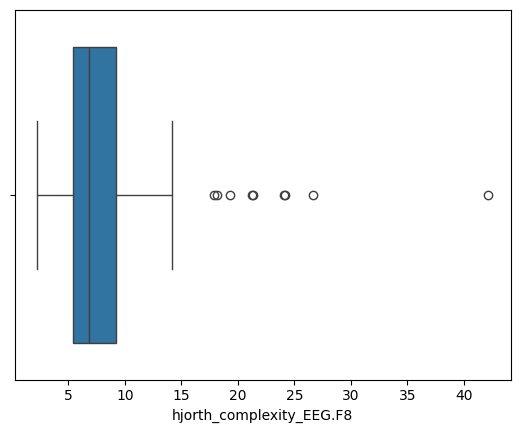

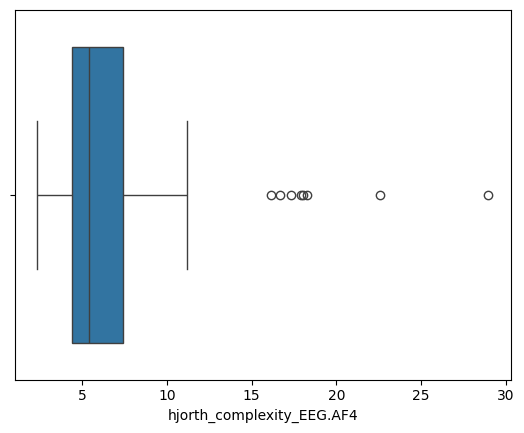

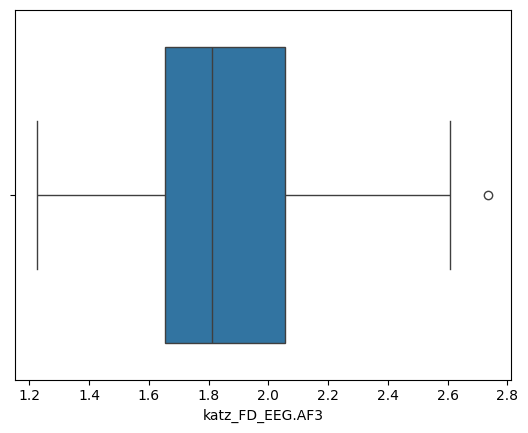

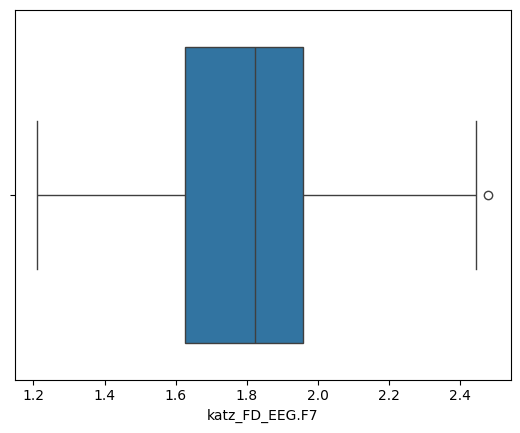

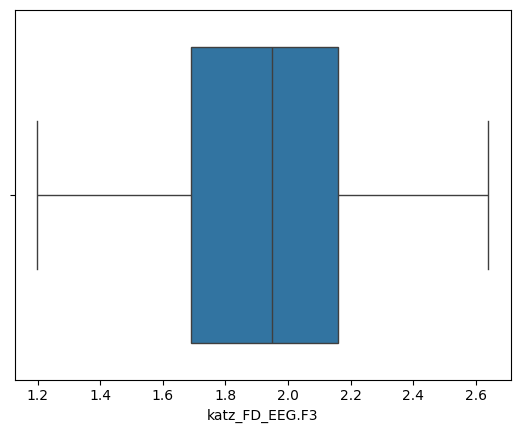

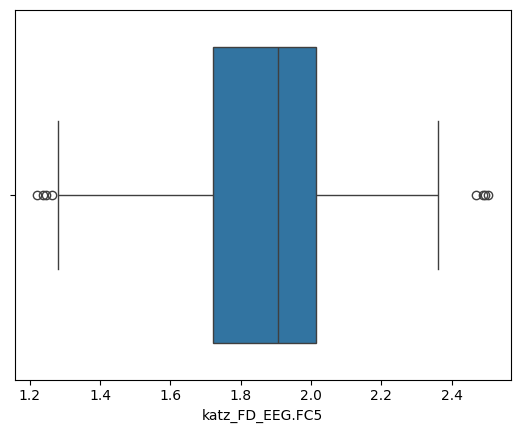

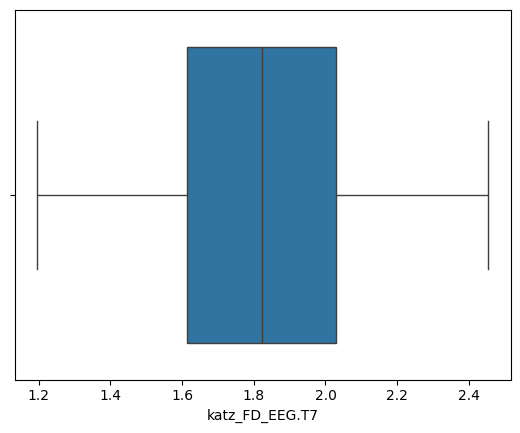

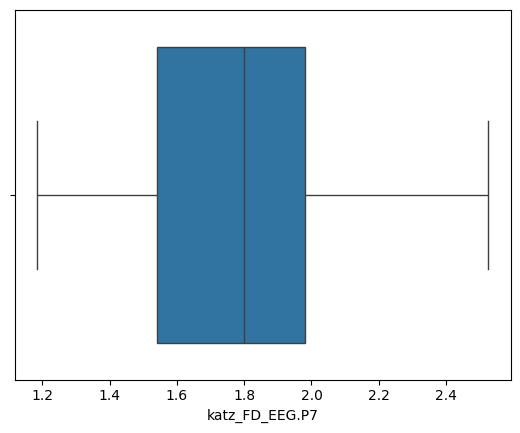

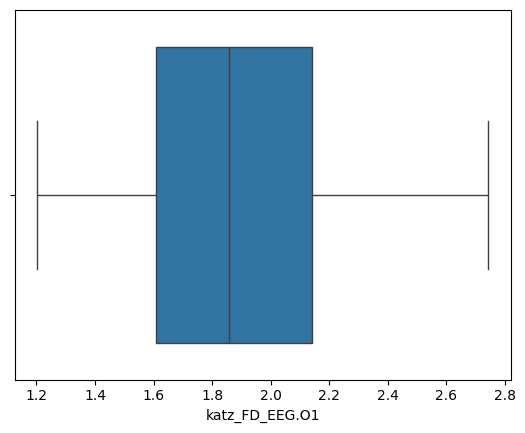

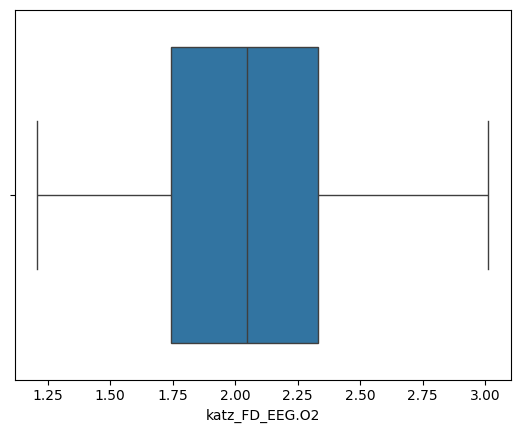

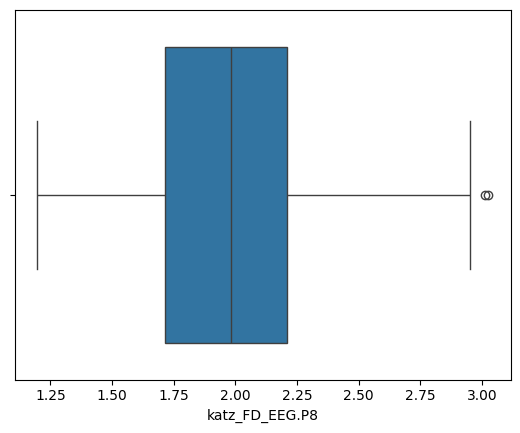

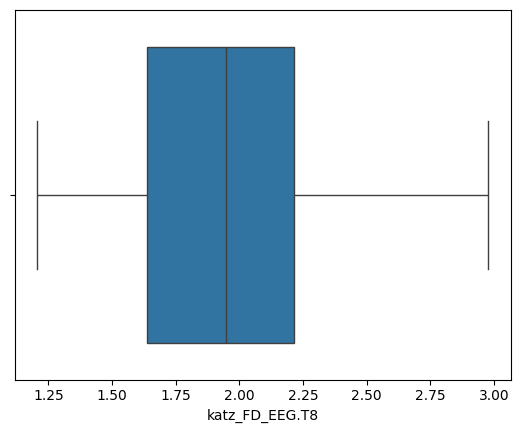

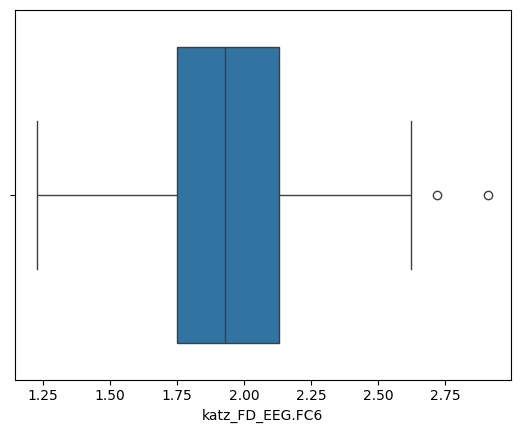

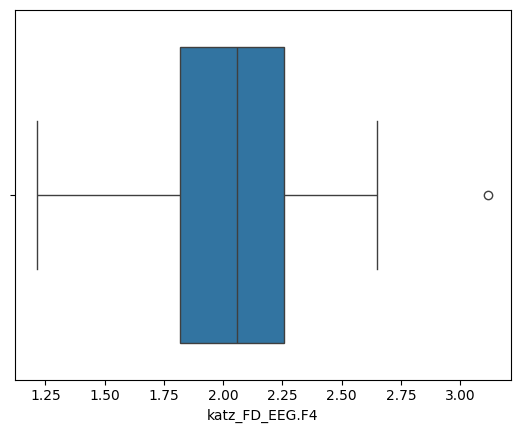

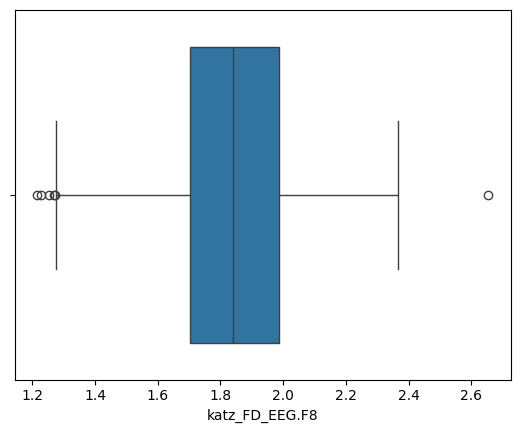

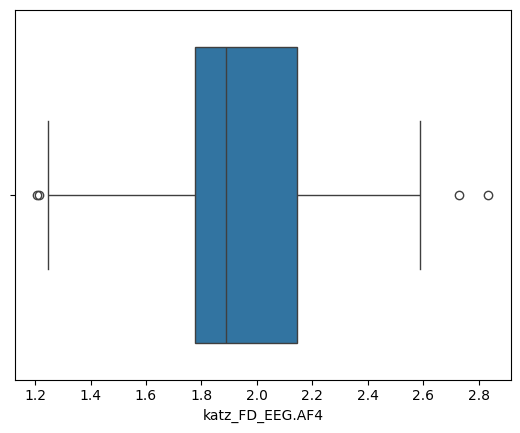

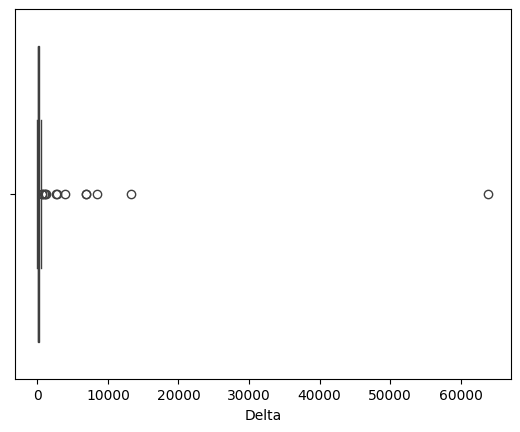

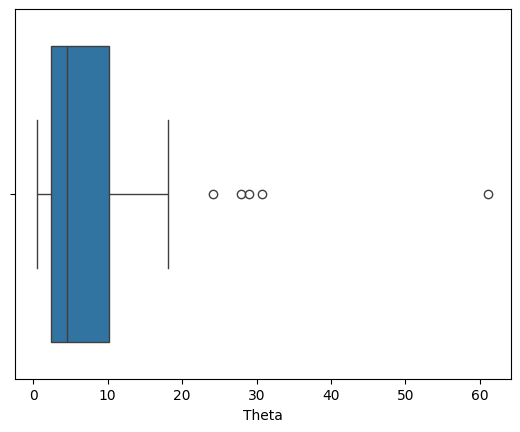

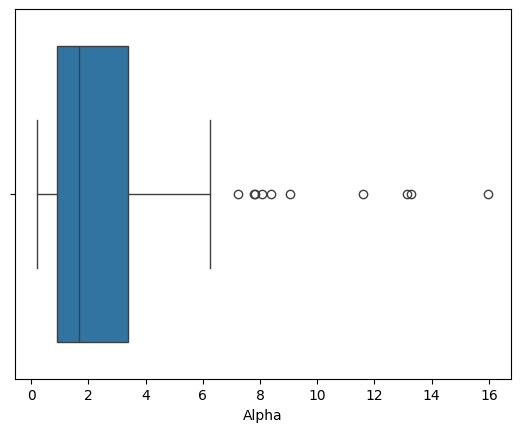

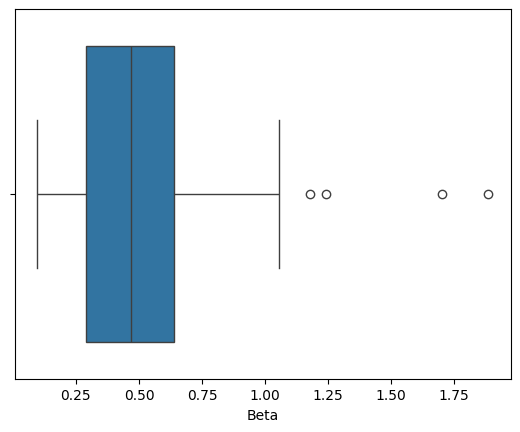

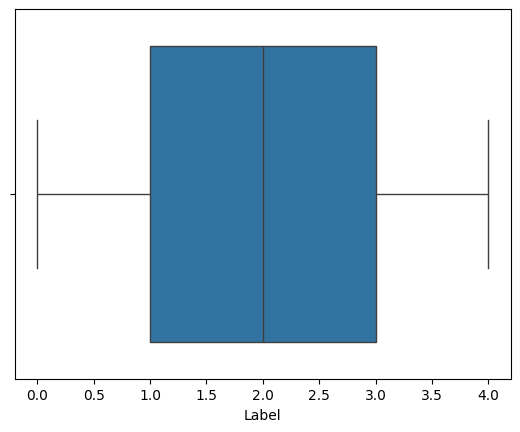

In [4]:
for col in feature_df.columns:
    sns.boxplot(x=feature_df[col])
    plt.show()

<Axes: >

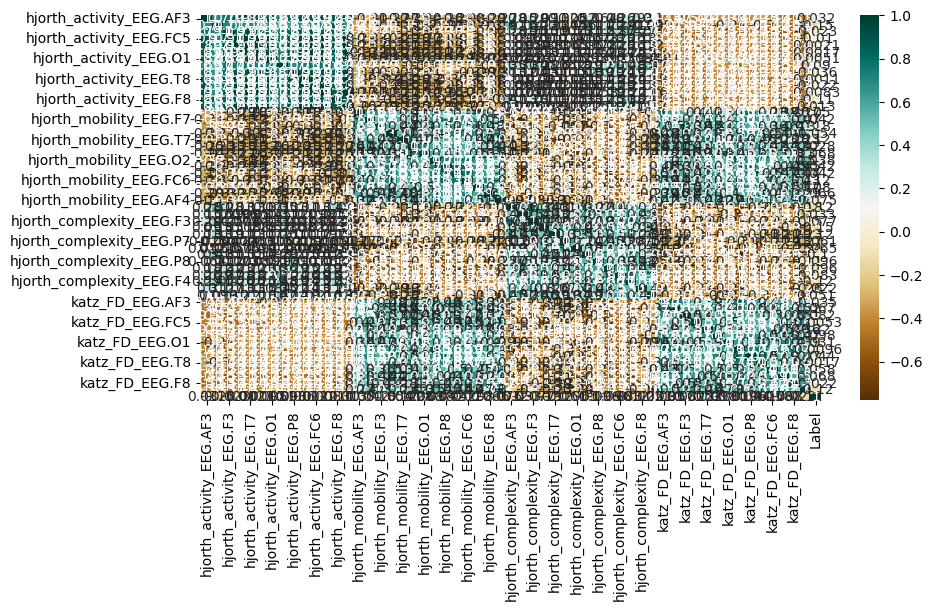

In [144]:
plt.figure(figsize=(10,5))
c= feature_df.corr()
sns.heatmap(c,cmap="BrBG",annot=True)

## pipeline

In [153]:
pipe = make_pipeline(StandardScaler(), svm.SVC())
pipe.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()), ('svc', SVC())])

In [154]:
pipe.score(X_val, y_val)

0.9

In [155]:
y_pred= pipe.predict(X_val)


# compute and print accuracy score
print('Model accuracy score with default hyperparameters: {0:0.4f}'. format(accuracy_score(y_val, y_pred)))

Model accuracy score with default hyperparameters: 0.9000


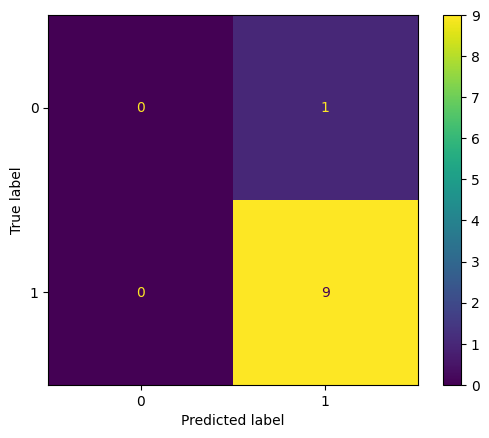

In [156]:
cm = confusion_matrix(y_val, y_pred, labels=pipe[1].classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=pipe[1].classes_)
disp.plot()

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector

# Backward Feature Selection
sfs = SequentialFeatureSelector(estimator=pipe, n_features_to_select=7, direction='backward')
sfs.fit(X_resampled, y_resampled)

# Selected feature indices
selected_features = sfs.get_support(indices=True)

In [ ]:
feature_df.columns[selected_features]

Index(['hjorth_activity_EEG.O2', 'hjorth_mobility_EEG.P8',
       'hjorth_mobility_EEG.F8', 'hjorth_complexity_EEG.T8',
       'hjorth_complexity_EEG.F4', 'katz_FD_EEG.FC6', 'katz_FD_EEG.AF4'],
      dtype='object')

## SVM

In [12]:
clf.fit(X_train, y_train)

SVC()

In [13]:
y_pred=clf.predict(X_train)


# compute and print accuracy score
print('Model accuracy score with default hyperparameters: {0:0.4f}'. format(accuracy_score(y_train, y_pred)))

Model accuracy score with default hyperparameters: 0.3793


### SVM Grid Search

In [102]:
from sklearn.model_selection import GridSearchCV 
  
# defining parameter range 
param_grid = {'C': [0.1, 1, 10, 100, 1000],  
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
              'kernel': ['rbf']}  
  
grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3) 
  
# fitting the model for grid search 
grid.fit(X_train, y_train) 

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.250 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.250 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.167 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.273 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.182 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.250 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.250 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.167 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.273 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.182 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.250 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [ ]:
grid_predictions = grid.predict(X_val) 
  
# print classification report 
print(classification_report(y_val, grid_predictions)) 

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.20      1.00      0.33         2
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         3

    accuracy                           0.20        10
   macro avg       0.05      0.25      0.08        10
weighted avg       0.04      0.20      0.07        10



C:\Users\lizoc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lizoc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\lizoc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classificati

In [84]:
# print best parameter after tuning 
print(grid.best_params_) 
  
# print how our model looks after hyper-parameter tuning 
print(grid.best_estimator_) 

{'C': 1, 'gamma': 1, 'kernel': 'rbf'}
SVC(C=1, gamma=1)


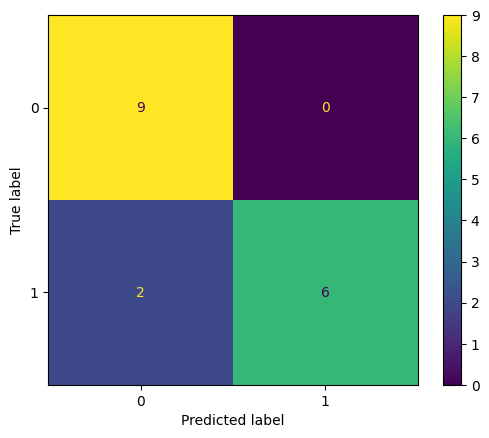

In [36]:
cm = confusion_matrix(y_val, y_pred, labels=pipe[1].classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=pipe[1].classes_)
disp.plot()

In [109]:
pipe[1]

SVC()

In [111]:
perm_importance

{'importances_mean': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0.]),
 'importances_std': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0.]),
 'importances': array([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0

Text(0.5, 0, 'Permutation Importance')

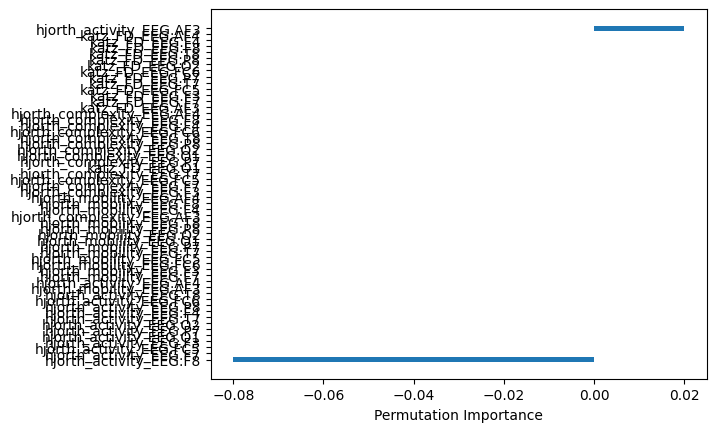

In [118]:
# perm_importance = permutation_importance(pipe[1], X_train, y_train)
# sorted_idx = perm_importance.importances_mean.argsort()

svc =  SVC(kernel='rbf', C=2)
svc.fit(X_train, y_train)

perm_importance = permutation_importance(svc, X_val, y_val)
sorted_idx = perm_importance.importances_mean.argsort()

plt.barh(feature_df.columns[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")
# plt.tight_layout()



In [114]:
feature_df.columns[sorted_idx]

Index(['hjorth_mobility_EEG.F7', 'hjorth_mobility_EEG.AF3',
       'hjorth_complexity_EEG.F7', 'hjorth_complexity_EEG.AF3',
       'hjorth_mobility_EEG.AF4', 'hjorth_mobility_EEG.F8',
       'hjorth_mobility_EEG.F4', 'hjorth_mobility_EEG.FC6',
       'hjorth_mobility_EEG.T8', 'hjorth_mobility_EEG.P8',
       'hjorth_mobility_EEG.O2', 'hjorth_mobility_EEG.O1',
       'hjorth_mobility_EEG.P7', 'hjorth_mobility_EEG.T7',
       'hjorth_mobility_EEG.FC5', 'hjorth_mobility_EEG.F3',
       'hjorth_complexity_EEG.F3', 'hjorth_complexity_EEG.FC5',
       'katz_FD_EEG.FC5', 'katz_FD_EEG.F3', 'katz_FD_EEG.F7',
       'katz_FD_EEG.AF3', 'hjorth_complexity_EEG.AF4',
       'hjorth_complexity_EEG.F8', 'hjorth_complexity_EEG.F4',
       'hjorth_complexity_EEG.FC6', 'hjorth_complexity_EEG.T8',
       'hjorth_complexity_EEG.P8', 'hjorth_complexity_EEG.O2',
       'hjorth_complexity_EEG.O1', 'hjorth_complexity_EEG.P7',
       'hjorth_complexity_EEG.T7', 'katz_FD_EEG.O1', 'katz_FD_EEG.O2',
       'katz_F

In [133]:
from sklearn.feature_selection import SequentialFeatureSelector

# Backward Feature Selection
sfs = SequentialFeatureSelector(estimator=pipe, n_features_to_select=7, direction='backward')
sfs.fit(X_train, y_train)

# Selected feature indices
selected_features = sfs.get_support(indices=True)

In [134]:
selected_features

array([ 1, 26, 31, 41, 43, 46, 55])

In [136]:
# Use selected features for training and testing
X_train_selected = X_train.to_numpy()[:, selected_features]
X_val_selected = X_val.to_numpy()[:, selected_features]

# Train SVM model with selected features
svm_selected = pipe
svm_selected.fit(X_train_selected, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()), ('svc', SVC())])

In [137]:
# Evaluate model performance
accuracy = svm_selected.score(X_val_selected, y_val)
print("Accuracy with selected features:", accuracy)

Accuracy with selected features: 0.2


## Random Forest

In [157]:
rf = make_pipeline(StandardScaler(), RandomForestClassifier())

In [158]:
rf.fit(X_resampled, y_resampled)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestclassifier', RandomForestClassifier())])

In [159]:
y_pred = rf.predict(X_val)


# compute and print accuracy score
print('Model accuracy score with default hyperparameters: {0:0.4f}'. format(accuracy_score(y_val, y_pred)))

Model accuracy score with default hyperparameters: 0.7000


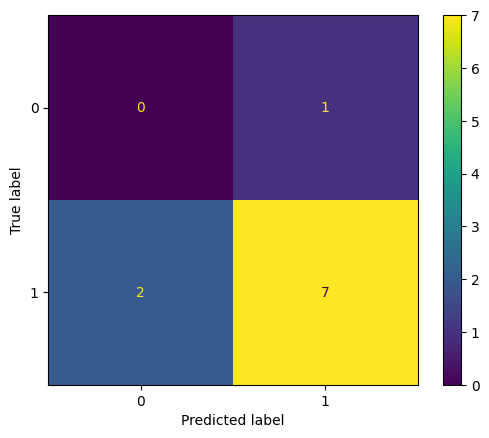

In [160]:
cm = confusion_matrix(y_val, y_pred, labels=pipe[1].classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=pipe[1].classes_)
disp.plot()

In [ ]:
rf.g